✅ Auto-detection successful.


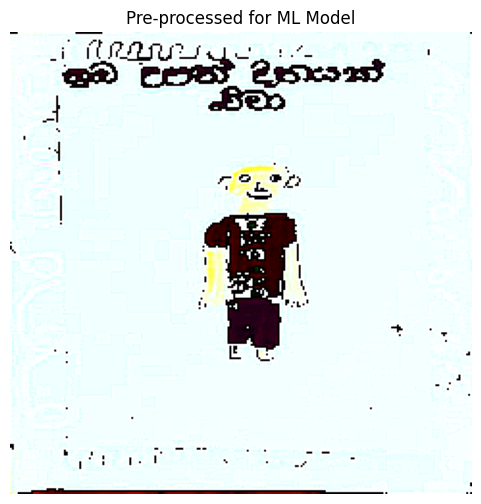

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the target size for your ML model
TARGET_SIZE = (240, 240)

def order_points(pts):
    """Orders coordinates: top-left, top-right, bottom-right, bottom-left."""
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def apply_kido_scanner_effect(img):
    """
    Transforms a photo into a clean 'Kido Dataset' style image:
    Pure white background and high-saturation drawing lines.
    """
    # Convert to LAB to isolate lighting (L) from color (A, B)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # BACKGROUND WHITENING:
    # Use a large morphological opening to estimate the 'paper' color/lighting
    kernel = np.ones((21, 21), np.uint8)
    bg = cv2.morphologyEx(l, cv2.MORPH_DILATE, kernel)
    bg = cv2.medianBlur(bg, 21)

    # Divide the original by the background to flatten shadows
    # This forces the paper to become nearly pure white
    diff = cv2.absdiff(l, bg)
    l = 255 - diff

    # Increase contrast of the L channel specifically
    l = cv2.threshold(l, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1] # Optional: for very clean white
    # If OTSU is too harsh, use this instead:
    # l = cv2.normalize(l, None, 0, 255, cv2.NORM_MINMAX)

    # Re-merge and boost saturation (A and B channels)
    # Multiplying A/B slightly makes the crayons 'pop'
    merged = cv2.merge((l, a, b))
    final = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    # Final sharpening
    kernel_sharpening = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    final = cv2.filter2D(final, -1, kernel_sharpening)

    return final

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    dst = np.array([[0, 0], [maxWidth - 1, 0], [maxWidth - 1, maxHeight - 1], [0, maxHeight - 1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(image, M, (maxWidth, maxHeight))

def process_drawing_pipeline(image_path):
    if not os.path.exists(image_path):
        print("Error: File not found")
        return None

    img = cv2.imread(image_path)
    orig = img.copy()
    h, w = img.shape[:2]

    # --- PHASE 1: AUTO DETECTION ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 75, 200)

    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    screenCnt = None
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            # VALIDATION: Paper should be at least 15% of the image area
            if cv2.contourArea(c) > (h * w * 0.15):
                screenCnt = approx
                break

    # --- PHASE 2: HANDLING RESULTS ---
    if screenCnt is not None:
        print("✅ Auto-detection successful.")
        warped = four_point_transform(orig, screenCnt.reshape(4, 2))
    else:
        # --- PHASE 3: THE 'DENIAL' & MANUAL ADJUSTMENT ---
        print("❌ Could not identify edges properly.")
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title("Manual Adjustment Needed\nPlease note the [x, y] coordinates of the 4 corners.")
        plt.show()

        print("Enter the 4 corner coordinates (Top-Left, Top-Right, Bottom-Right, Bottom-Left):")
        try:
            # Example input format: 50,50 400,50 400,600 50,600
            user_input = input("Format: x1,y1 x2,y2 x3,y3 x4,y4 (or type 'cancel'): ")
            if user_input.lower() == 'cancel': return None

            pts = np.array([list(map(int, p.split(','))) for p in user_input.split(' ')], dtype="float32")
            warped = four_point_transform(orig, pts)
        except:
            print("Invalid input. Processing denied.")
            return None

    # --- PHASE 4: PRE-PROCESSING (The Kido Look) ---
    resized = cv2.resize(warped, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    final_output = apply_kido_scanner_effect(resized)

    return final_output

# RUN SCRIPT
input_filename = "wood bg1.jpeg"  # Ensure this path is correct
processed_result = process_drawing_pipeline(input_filename)

if processed_result is not None:
    img_display = cv2.cvtColor(processed_result, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.title("Pre-processed for ML Model")
    plt.axis('off')
    plt.show()
    cv2.imwrite("ready_for_training.png", processed_result)